# Import libraries

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import json
import os
from shapely.geometry import shape
from pathlib import Path
from __future__ import annotations

In [2]:
oc_features_dir = "/Users/arleth/Desktop/calgary-dashboard/data/calgary/processed_data/open_calgary/20260327/features"
oc_metadata_dir = "/Users/arleth/Desktop/calgary-dashboard/data/calgary/processed_data/open_calgary/20260327/metadata"

## Utilities

In [3]:
def viz_gdf(_gdf):
    # Visualize the geometry objects using GeoPandas plotting
    _gdf.plot(column=None, edgecolor='black', figsize=(5, 3))
    plt.title("Geometry Visualization")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()
    return plt

In [4]:
def load_gdf(_file):
    return gpd.read_parquet(_file)
def load_json(_file):
    with open(_file, "r") as f:
        return json.load(f)

# Load desired metadata and parquet file(s)

## Load and visualize parquet

In [13]:
# Load and preview parquet file in geopandas
file = "/Users/arleth/Research_Work/calgary-dashboard/data/calgary/processed_data/statcan/20260507/features/98100015_PopulationAndDwellingCountsCanada_features.parquet"

# Get feature columns
gdf = gpd.read_parquet(file)
gdf.head()

,DAUID,DGUID,LANDAREA,PRUID,geometry,REF_DATE,GEO,Coordinate,"Population and dwelling counts (5): Population, 2021 [1]","Population and dwelling counts (5): Total private dwellings, 2021 [2]","Population and dwelling counts (5): Private dwellings occupied by usual residents, 2021 [3]","Population and dwelling counts (5): Land area in square kilometres, 2021 [4]","Population and dwelling counts (5): Population density per square kilometre, 2021 [5]"
0,48061727,2021S051248061727,0.0938,48,"POLYGON ((4698675.58 1948557.146, 4698619.866 ...",2021,48061727,48489,423.0,167.0,163.0,0.09,4509.6
1,48061730,2021S051248061730,0.1400,48,"POLYGON ((4697457.103 1947482.246, 4697524.837...",2021,48061730,48490,476.0,166.0,161.0,0.14,3400.0
2,48061732,2021S051248061732,0.0442,48,"POLYGON ((4696845.7 1946852.951, 4696841.386 1...",2021,48061732,48491,239.0,82.0,80.0,0.04,5407.2
3,48061733,2021S051248061733,0.5657,48,"POLYGON ((4697150.526 1948356.509, 4697109.969...",2021,48061733,48492,1013.0,374.0,368.0,0.57,1790.7
4,48061734,2021S051248061734,0.0836,48,"POLYGON ((4697109.969 1948244.054, 4697153.551...",2021,48061734,48493,335.0,123.0,120.0,0.08,4007.2


In [9]:
gdf.iloc[0]

DAUID                                                                                                                                   48061727
DGUID                                                                                                                          2021S051248061727
LANDAREA                                                                                                                                  0.0938
PRUID                                                                                                                                         48
geometry                                                                                       POLYGON ((4698675.580000071 1948557.1457144814...
REF_DATE                                                                                                                                    2021
GEO                                                                                                                               

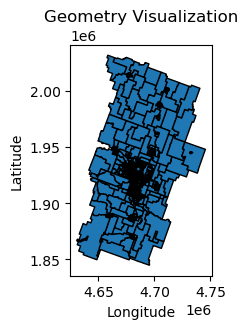

In [10]:
# Visualize the geometry objects using GeoPandas plotting
gdf.plot(column=None, edgecolor='black', figsize=(5, 3))
plt.title("Geometry Visualization")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

## View Open Calgary that is not in Parquet file format

In [ ]:
file = "/Users/arleth/Desktop/calgary-dashboard/data/calgary/processed_data/open_calgary/20260327/features/crbp-innf_CorporateEnergy_feature.json"

data = load_json(file)

# If data is a list of dicts, convert directly. Otherwise, adapt as needed.
df = pd.DataFrame(data)

df.head()

In [ ]:
df.iloc[0]

In [ ]:
df['energy_description'].unique()

In [ ]:
# Load and preview .json metadata file with pandas
file = "/sci-it/hosts/olympus/calgary/processed_data/open_calgary/20260327/metadata/k85e-i265_ResidentialSolarPhotovoltaicPvSystem_metadata.json"

with open(file, "r") as f:
    data = json.load(f)

keys_to_use = ["id", "name", "attribution", "createdAt", "description", "custom_fields", "metadata", "owner", "rights"]

for k in keys_to_use:
    try:
        print(k)
        print(data[k])
        print("--------------------------------")
    except:
        print(f"Error: {k} not found in metadata")
        pass


## ENMAX

In [ ]:
gdf = load_gdf("/sci-it/hosts/olympus/calgary/processed_data/enmax/20260327/features/polygon/EnmaxDistributionLimit_features.parquet")
gdf.head()

In [ ]:
viz_gdf(gdf)

In [ ]:
# Load and preview .json metadata file with pandas
metadata = load_json("/sci-it/hosts/olympus/calgary/processed_data/enmax/20260327/metadata/EnmaxServiceArea_metadata.json")

keys_to_use = ["name", "description", "copyrightText", "editingInfo", "spatialReference"]

for k in keys_to_use:
    print(k)
    print(metadata[k])
    print("--------------------------------")


## Preview Open Calgary metadata from feature and metadata files

In [ ]:
# Print metadata keys of the corresponding metadata file in metadata_dir
for feature_file in os.listdir(oc_features_dir):
    # Expect corresponding metadata file with same base name but ending in _metadata.json
    if feature_file.endswith(".json"):
        base = feature_file.rsplit("_feature", 1)[0]
        metadata_file = f"{base}_metadata.json"

        metadata_path = os.path.join(oc_metadata_dir, metadata_file)
        feature_path = os.path.join(oc_features_dir, feature_file)

        with open(metadata_path, "r") as f:
            metadata = json.load(f)

        with open(feature_path, "r") as f:
            feature = json.load(f)

        print(f"~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
        print(f"\n--- {metadata_file} ---")
        print("Metadata keys:", list(metadata.keys()))
        print(f"\n--- {feature_file} ---")
        print("Feature keys:", list(feature[0].keys()))


## Preview metadata in all Open Calgary parquet files

In [ ]:
oc_parquet_dirs = [f"{oc_features_dir}/{d}" for d in os.listdir(oc_features_dir) if os.path.isdir(f"{oc_features_dir}/{d}")]

for parquet_dir in oc_parquet_dirs:
    for feature_file in os.listdir(parquet_dir):
        base = feature_file.rsplit("_feature", 1)[0]
        metadata_file = f"{base}_metadata.json"

        metadata_path = os.path.join(oc_metadata_dir, metadata_file)
        feature_path = os.path.join(parquet_dir, feature_file)
        
        with open(metadata_path, "r") as f:
            metadata = json.load(f)

        gdf = gpd.read_parquet(path)

        print(f"~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
        print(f"\n--- {metadata_file} ---")
        print("Metadata keys:", list(metadata.keys()))
        print(f"\n--- {feature_file} ---")
        print("Feature columns:", gdf.columns)



## Preview metadata in all ENMAX parquet files

In [ ]:
en_features_dir = "/sci-it/hosts/olympus/calgary/processed_data/enmax/20260327/features"
en_metadata_dir = "/sci-it/hosts/olympus/calgary/processed_data/enmax/20260327/metadata"
en_parquet_dirs = [f"{en_features_dir}/{d}" for d in os.listdir(en_features_dir) if os.path.isdir(f"{en_features_dir}/{d}")]

for parquet_dir in en_parquet_dirs:
    for feature_file in os.listdir(parquet_dir):
        base = feature_file.rsplit("_feature", 1)[0]
        metadata_file = f"{base}_metadata.json"
        metadata_path = os.path.join(en_metadata_dir, metadata_file)
        feature_path = os.path.join(parquet_dir, feature_file)
        try:
            # Get metadata
            with open(metadata_path, "r") as f:
                metadata = json.load(f)
            # Get feature columns
            gdf = gpd.read_parquet(feature_path)
            print(f"~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
            print(f"\n--- {metadata_file} ---")
            print("Metadata keys:", list(metadata.keys()))
            print(f"\n--- {feature_file} ---")
            print("Feature columns:", gdf.columns)
        except Exception as e:
            print(f"Failed to process {feature_file}: {e}")
